# Pest Identification - TensorFlow Training Pipeline

End-to-end notebook: data discovery, preparation, preprocessing, visualization, training, evaluation, and model export.


**Section: Setup**

In [38]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

import tensorflow as tf

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path('dataset')
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

# Preprocessing toggles
FILTER_QUALITY = True
BLUR_THRESHOLD = 15.0  # lower -> more strict (tune as needed)
BRIGHTNESS_MIN = 20.0  # 0-255
BRIGHTNESS_MAX = 235.0 # 0-255
USE_CACHE = True


**Section: Data Discovery**

**1) Dataset Scan**

In [39]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Dataset folder not found: {DATA_DIR.resolve()}')

class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
if not class_names:
    raise ValueError('No class folders found inside dataset/')

print('Classes:', class_names)

image_paths = []
labels = []
for idx, cls in enumerate(class_names):
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        for p in (DATA_DIR / cls).glob(ext):
            image_paths.append(str(p))
            labels.append(idx)

image_paths = np.array(image_paths)
labels = np.array(labels)
print('Total images:', len(image_paths))


Classes: ['Cecidomyiidae', 'Chloropidae', 'Cicadellidae', 'Crambidae', 'Curculionidae', 'Delphacidae', 'Phlaeothripidae']
Total images: 2100


**2) Per-Class Counts and Imbalance**

Counts per class:
Cecidomyiidae: 300
Chloropidae: 300
Cicadellidae: 300
Crambidae: 300
Curculionidae: 300
Delphacidae: 300
Phlaeothripidae: 300
Imbalance ratio (max/min): 1.00


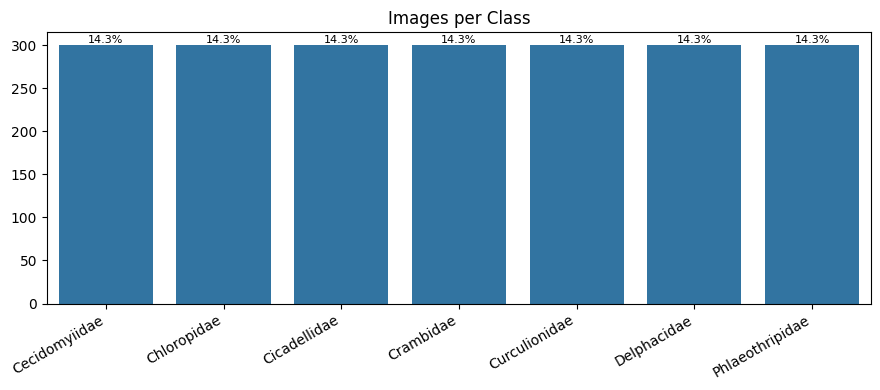

In [40]:
counts = Counter(labels)
counts_per_class = [counts[i] for i in range(len(class_names))]
min_c = min(counts_per_class)
max_c = max(counts_per_class)
imbalance_ratio = max_c / max(1, min_c)
print('Counts per class:')
for name, c in zip(class_names, counts_per_class):
    print(f'{name}: {c}')
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

# Bar chart with counts and percentages
total = sum(counts_per_class)
pct = [c / total * 100 for c in counts_per_class]
plt.figure(figsize=(9, 4))
ax = sns.barplot(x=class_names, y=counts_per_class)
plt.xticks(rotation=30, ha='right')
plt.title('Images per Class')
for i, v in enumerate(counts_per_class):
    ax.text(i, v + max(counts_per_class) * 0.01, f'{pct[i]:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


**3) Image Size and Aspect Ratio Distribution**

Width: min=120 max=2638 mean=419.0
Height: min=119 max=1909 mean=406.8


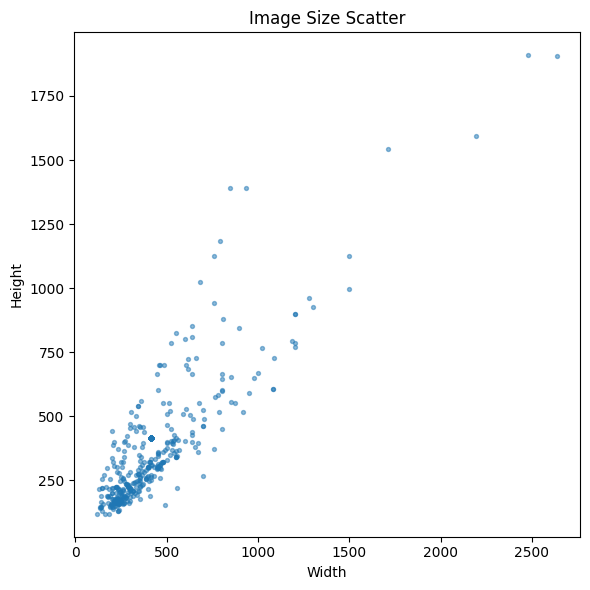

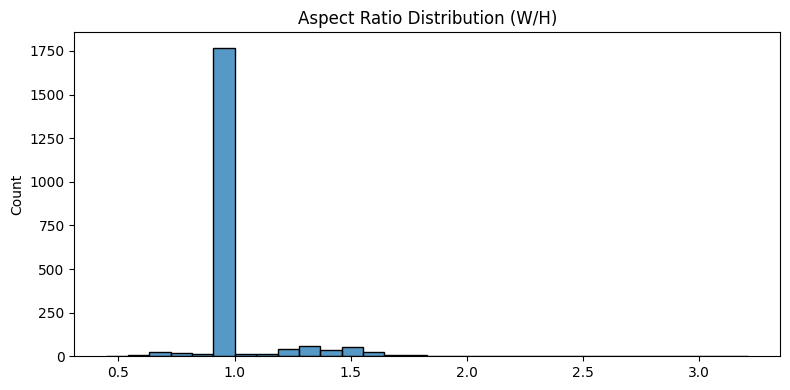

In [41]:
sizes = []
aspects = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            w, h = img.size
            sizes.append((w, h))
            if h > 0:
                aspects.append(w / h)
    except Exception:
        pass

sizes = np.array(sizes)
if len(sizes) > 0:
    widths, heights = sizes[:, 0], sizes[:, 1]
    print(f'Width: min={widths.min()} max={widths.max()} mean={widths.mean():.1f}')
    print(f'Height: min={heights.min()} max={heights.max()} mean={heights.mean():.1f}')

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, s=8, alpha=0.5)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Image Size Scatter')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(aspects, bins=30)
plt.title('Aspect Ratio Distribution (W/H)')
plt.tight_layout()
plt.show()


**4) Corrupt / Unreadable Image Detection**

In [42]:
bad_files = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            img.verify()
    except Exception:
        bad_files.append(p)

print(f'Corrupt or unreadable images: {len(bad_files)}')
if bad_files[:10]:
    print('Examples:')
    for bf in bad_files[:10]:
        print(' -', bf)


Corrupt or unreadable images: 0


**5) Duplicate / Near-Duplicate Detection (Perceptual Hash)**

In [43]:
# Warning: This can be slow on large datasets
hashes = {}
duplicates = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            h = imagehash.phash(img)
        if h in hashes:
            duplicates.append((hashes[h], p))
        else:
            hashes[h] = p
    except Exception:
        pass

print(f'Exact/near duplicates found: {len(duplicates)}')
if duplicates[:10]:
    print('Examples:')
    for a, b in duplicates[:10]:
        print(' -', a, '==', b)


Exact/near duplicates found: 496
Examples:
 - dataset/Cecidomyiidae/5 (745).jpg == dataset/Cecidomyiidae/5 (769).jpg
 - dataset/Cecidomyiidae/5 (551).jpg == dataset/Cecidomyiidae/5 (580).jpg
 - dataset/Cecidomyiidae/5 (549).jpg == dataset/Cecidomyiidae/5 (725).jpg
 - dataset/Cecidomyiidae/5 (721).jpg == dataset/Cecidomyiidae/5 (480).jpg
 - dataset/Cecidomyiidae/5 (721).jpg == dataset/Cecidomyiidae/5 (545).jpg
 - dataset/Cecidomyiidae/5 (765).jpg == dataset/Cecidomyiidae/5 (543).jpg
 - dataset/Cecidomyiidae/5 (764).jpg == dataset/Cecidomyiidae/5 (588).jpg
 - dataset/Cecidomyiidae/5 (662).jpg == dataset/Cecidomyiidae/5 (733).jpg
 - dataset/Cecidomyiidae/5 (721).jpg == dataset/Cecidomyiidae/5 (651).jpg
 - dataset/Cecidomyiidae/5 (652).jpg == dataset/Cecidomyiidae/5 (643).jpg


**6) Brightness Distribution**

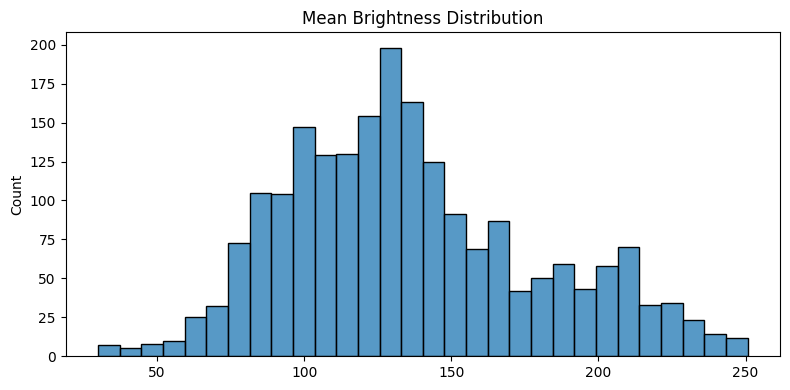

In [44]:
brightness_vals = []
brightness_labels = []
for p, y in zip(image_paths, labels):
    try:
        with Image.open(p).convert('L') as img:
            arr = np.array(img, dtype=np.float32)
            brightness_vals.append(arr.mean())
            brightness_labels.append(y)
    except Exception:
        pass

plt.figure(figsize=(8, 4))
sns.histplot(brightness_vals, bins=30)
plt.title('Mean Brightness Distribution')
plt.tight_layout()
plt.show()


**6b) Brightness by Class**

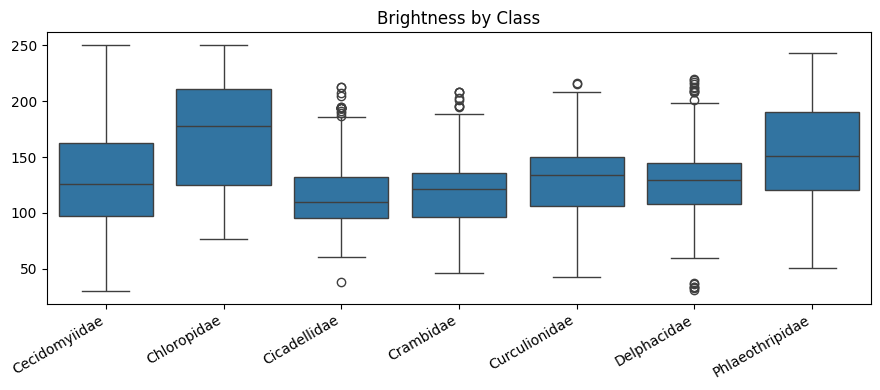

In [45]:
if len(brightness_vals) > 0:
    plt.figure(figsize=(9, 4))
    data = []
    for b, y in zip(brightness_vals, brightness_labels):
        data.append((class_names[y], b))
    xs = [d[0] for d in data]
    ys = [d[1] for d in data]
    sns.boxplot(x=xs, y=ys)
    plt.xticks(rotation=30, ha='right')
    plt.title('Brightness by Class')
    plt.tight_layout()
    plt.show()


**7) Visual Label Audit (Sample per Class)**

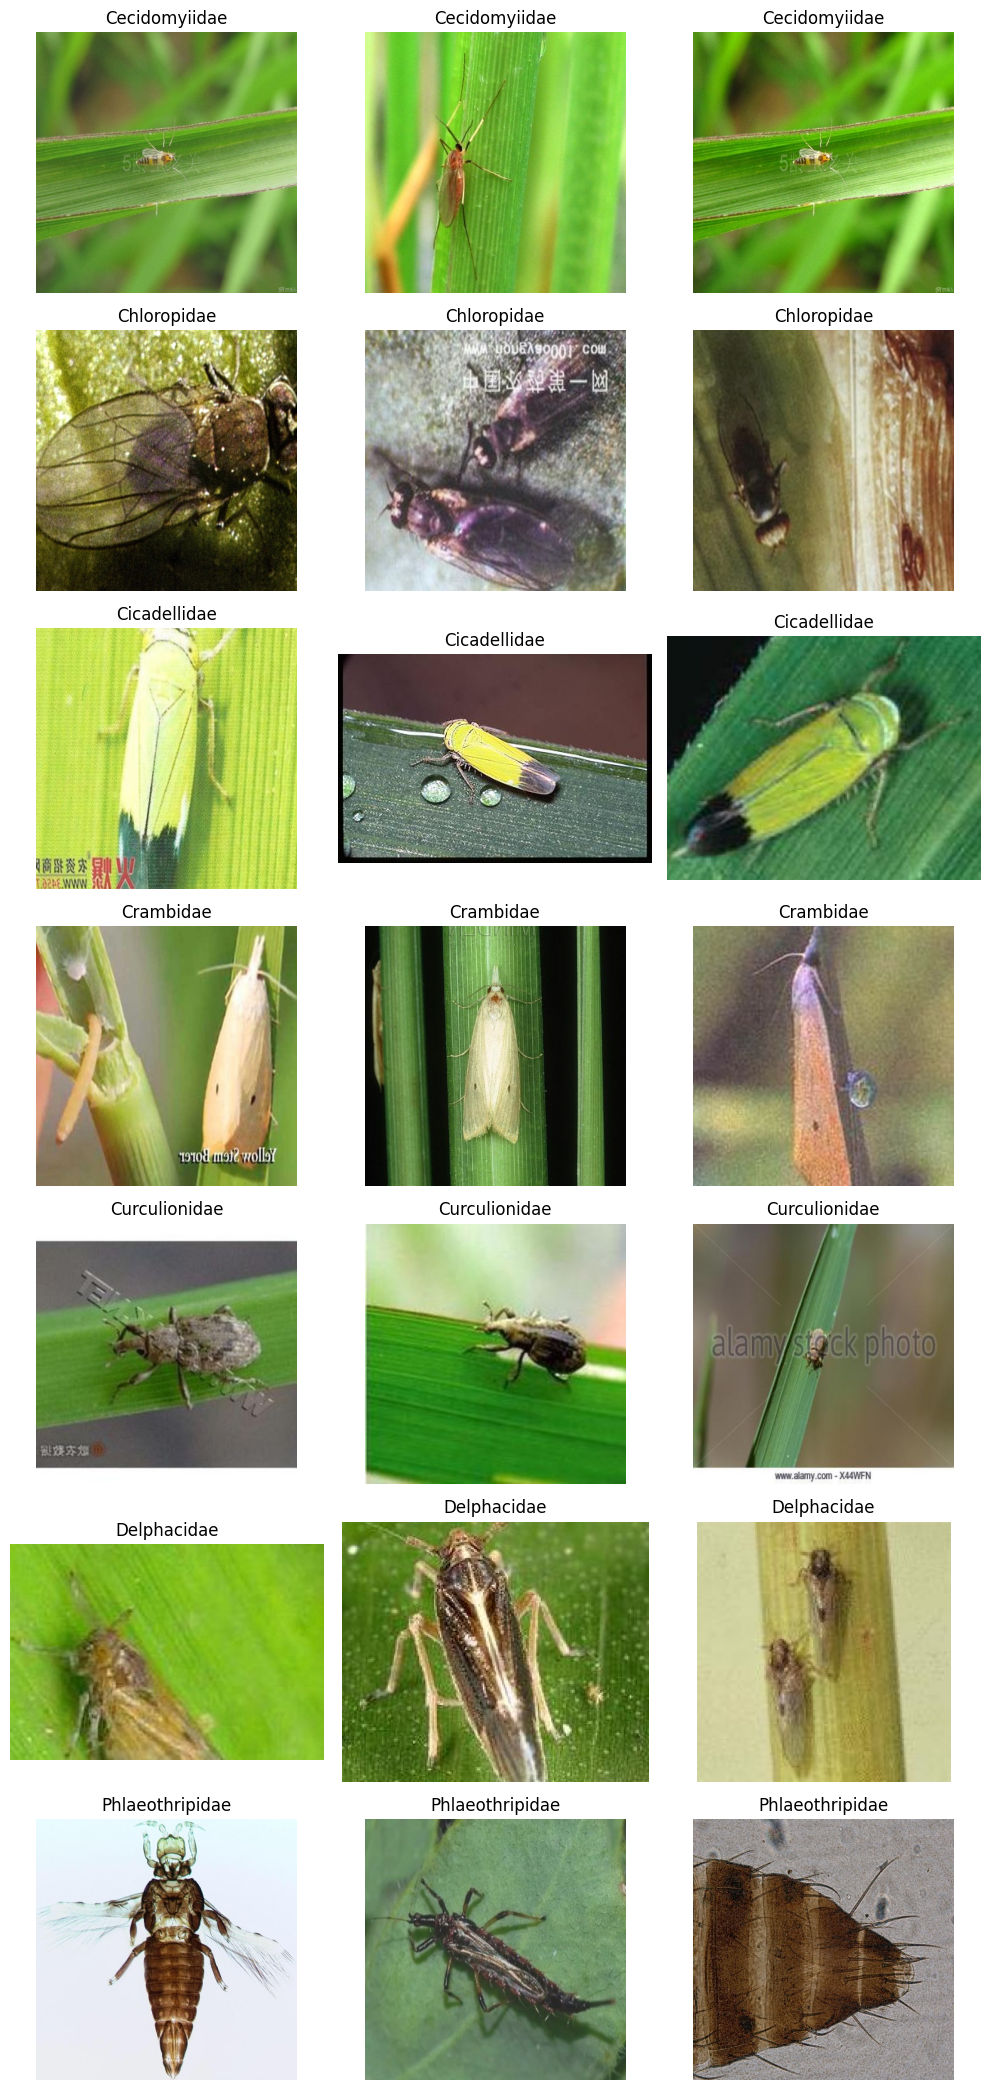

In [46]:
samples_per_class = 3
plt.figure(figsize=(10, 3 * len(class_names)))
row = 0
for idx, cls in enumerate(class_names):
    cls_paths = [p for p, y in zip(image_paths, labels) if y == idx]
    random.shuffle(cls_paths)
    for i in range(min(samples_per_class, len(cls_paths))):
        ax = plt.subplot(len(class_names), samples_per_class, row + i + 1)
        img = Image.open(cls_paths[i])
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
    row += samples_per_class
plt.tight_layout()
plt.show()


**8) Train/Val/Test Split (Stratified) and Check**

In [47]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

def show_split_stats(name, lbls):
    c = Counter(lbls)
    print(name)
    for i, cls in enumerate(class_names):
        print(f'  {cls}: {c.get(i, 0)}')

show_split_stats('Train', train_labels)
show_split_stats('Val', val_labels)
show_split_stats('Test', test_labels)


Train
  Cecidomyiidae: 210
  Chloropidae: 210
  Cicadellidae: 210
  Crambidae: 210
  Curculionidae: 210
  Delphacidae: 210
  Phlaeothripidae: 210
Val
  Cecidomyiidae: 45
  Chloropidae: 45
  Cicadellidae: 45
  Crambidae: 45
  Curculionidae: 45
  Delphacidae: 45
  Phlaeothripidae: 45
Test
  Cecidomyiidae: 45
  Chloropidae: 45
  Cicadellidae: 45
  Crambidae: 45
  Curculionidae: 45
  Delphacidae: 45
  Phlaeothripidae: 45


**9) Class Similarity Check (Quick Embedding + PCA)**

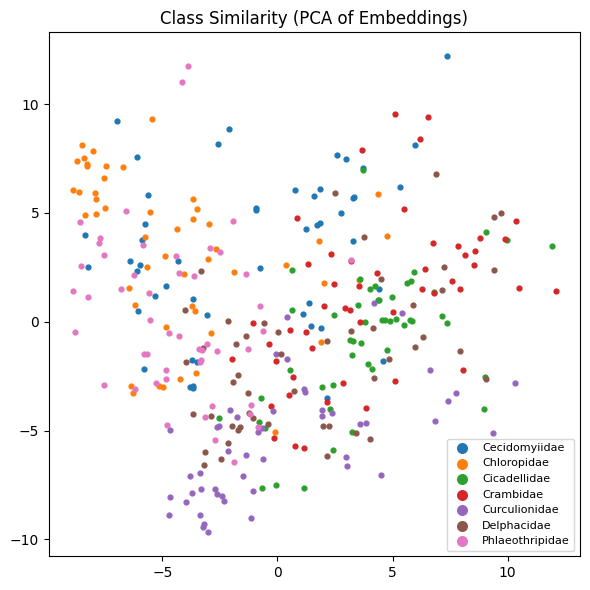

In [48]:
# Optional: quick clustering view using a pretrained encoder
# Sample up to 50 images per class for speed
sample_paths = []
sample_labels = []
max_per_class = 50
for i, cls in enumerate(class_names):
    cls_paths = [p for p, y in zip(image_paths, labels) if y == i]
    random.shuffle(cls_paths)
    take = cls_paths[:max_per_class]
    sample_paths.extend(take)
    sample_labels.extend([i] * len(take))

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img

encoder = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling='avg'
)

sample_ds = tf.data.Dataset.from_tensor_slices(sample_paths)
sample_ds = sample_ds.map(load_img_array, num_parallel_calls=AUTOTUNE).batch(32)
features = encoder.predict(sample_ds, verbose=0)
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(features)

plt.figure(figsize=(6, 6))
for i, cls in enumerate(class_names):
    idxs = [j for j, y in enumerate(sample_labels) if y == i]
    plt.scatter(coords[idxs, 0], coords[idxs, 1], label=cls, s=12)
plt.title('Class Similarity (PCA of Embeddings)')
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()


**Section: Data Preprocessing**

**1) Quality Filtering (Blurry / Too Dark / Too Bright)**

In [49]:
def sharpness_score(gray_arr):
    # Simple Laplacian-based sharpness approximation
    lap = (
        -4 * gray_arr
        + np.roll(gray_arr, 1, 0) + np.roll(gray_arr, -1, 0)
        + np.roll(gray_arr, 1, 1) + np.roll(gray_arr, -1, 1)
    )
    return lap.var()

def image_quality_ok(path):
    try:
        with Image.open(path).convert('L') as img:
            arr = np.array(img, dtype=np.float32)
        mean_brightness = arr.mean()
        sharpness = sharpness_score(arr)
        if mean_brightness < BRIGHTNESS_MIN or mean_brightness > BRIGHTNESS_MAX:
            return False
        if sharpness < BLUR_THRESHOLD:
            return False
        return True
    except Exception:
        return False

if FILTER_QUALITY:
    keep_paths = []
    keep_labels = []
    removed = 0
    for p, y in zip(image_paths, labels):
        if image_quality_ok(p):
            keep_paths.append(p)
            keep_labels.append(y)
        else:
            removed += 1
    image_paths = np.array(keep_paths)
    labels = np.array(keep_labels)
    print(f'Removed {removed} low-quality images')
    print(f'Remaining images: {len(image_paths)}')


Removed 65 low-quality images
Remaining images: 2035


**2) Train/Val/Test Split After Filtering**

In [50]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)


**3) Class Weights for Imbalance**

In [51]:
counts = Counter(train_labels)
total = len(train_labels)
class_weight = {i: total / (len(class_names) * counts.get(i, 1)) for i in range(len(class_names))}
print('Class weights:', class_weight)


Class weights: {0: 1.0996138996138995, 1: 1.0120824449182657, 2: 0.9687074829931973, 3: 0.9733424470266575, 4: 0.978021978021978, 5: 0.9733424470266575, 6: 1.007072135785007}


**4) TF Dataset + Augmentation + Caching**

In [52]:
NUM_CLASSES = len(class_names)

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.convert_image_dtype(img, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def build_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if USE_CACHE:
        ds = ds.cache()
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_paths, train_labels, training=True)
val_ds = build_dataset(val_paths, val_labels)
test_ds = build_dataset(test_paths, test_labels)


**Section: Visualization (Improved)**

**1) Sample Images**

2026-02-27 02:59:55.948735: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-02-27 02:59:55.994351: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


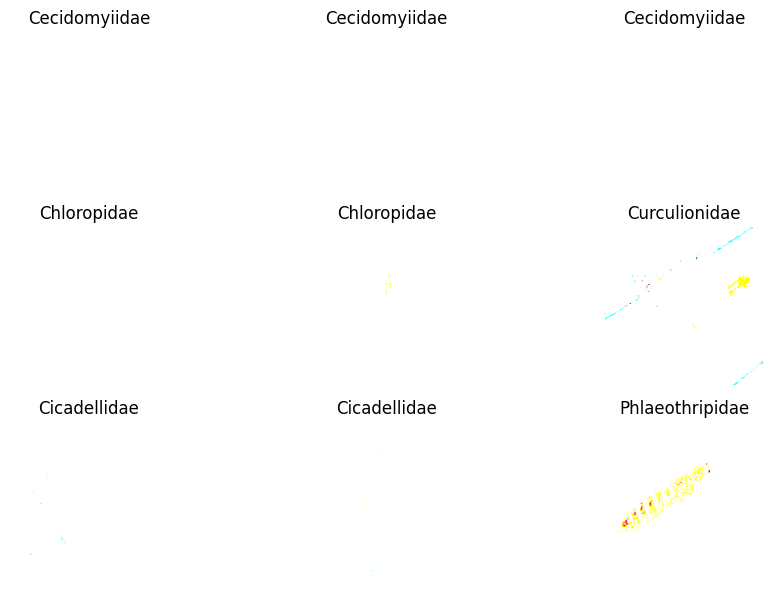

In [53]:
plt.figure(figsize=(10, 6))
for images, labels_batch in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        label_idx = int(tf.argmax(labels_batch[i]).numpy())
        plt.title(class_names[label_idx])
        plt.axis('off')
plt.tight_layout()
plt.show()


**2) Augmentation Preview**

2026-02-27 02:59:56.179753: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


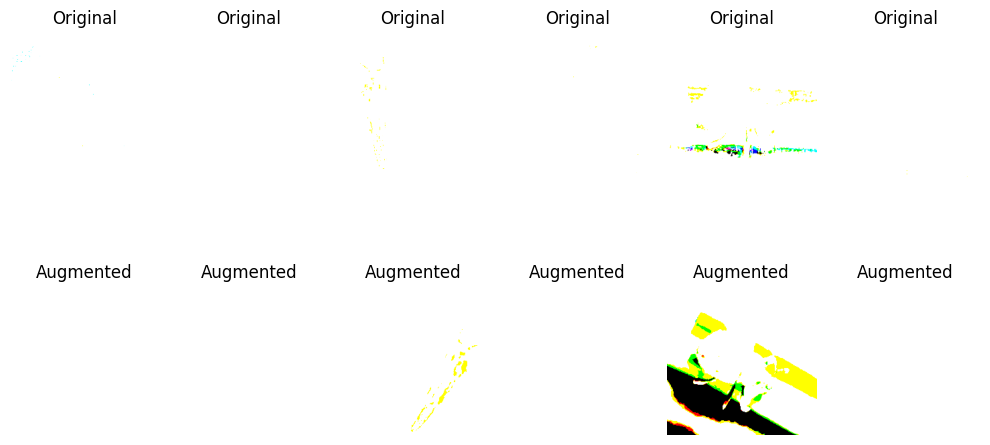

In [54]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])

# Take a small batch and show original vs augmented
sample_batch = next(iter(train_ds))
images, labels_batch = sample_batch
augmented = data_augmentation(images)

plt.figure(figsize=(10, 6))
for i in range(min(6, images.shape[0])):
    ax = plt.subplot(2, 6, i + 1)
    plt.imshow(images[i])
    plt.title('Original')
    plt.axis('off')
    ax = plt.subplot(2, 6, i + 7)
    plt.imshow(augmented[i])
    plt.title('Augmented')
    plt.axis('off')
plt.tight_layout()
plt.show()


**Section: Model**

In [55]:
# Use the same augmentation in the model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Section: Training**

In [56]:
Path('models').mkdir(exist_ok=True)
checkpoint_path = 'models/best_model.keras'

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)


Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.6110 - loss: 1.1437 - val_accuracy: 0.8459 - val_loss: 0.5412
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8588 - loss: 0.4865 - val_accuracy: 0.9016 - val_loss: 0.3539
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.8820 - loss: 0.3706 - val_accuracy: 0.9180 - val_loss: 0.2803
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9185 - loss: 0.2878 - val_accuracy: 0.9344 - val_loss: 0.2449
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9291 - loss: 0.2296 - val_accuracy: 0.9344 - val_loss: 0.2170
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.9382 - loss: 0.2104 - val_accuracy: 0.9541 - val_loss: 0.1954
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9586 - loss: 0.1783 - val_accuracy: 0.9541 - val_loss: 0.1855
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9621 - loss: 0.1530 - val_accuracy: 0.9607 -

**Section: Training Curves**

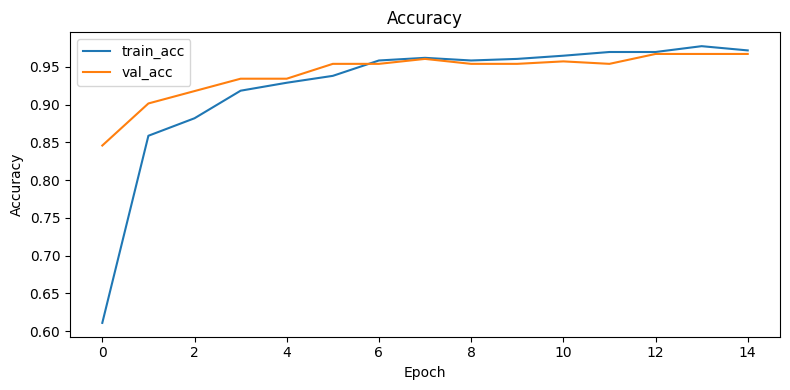

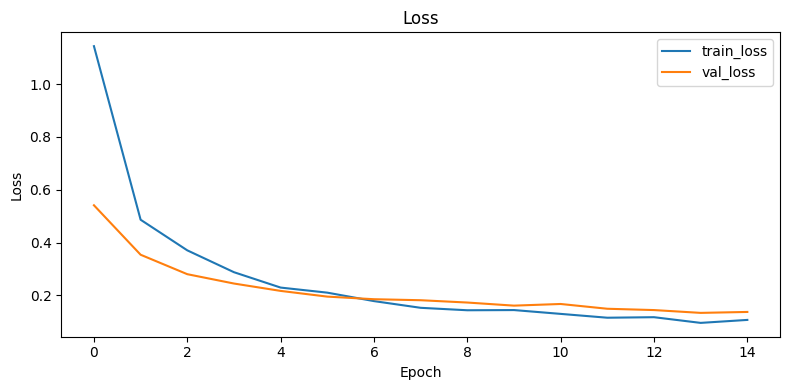

In [57]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()


**Section: Evaluation**

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9608 - loss: 0.1450
Test accuracy: 0.9608


2026-02-27 03:02:04.157330: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


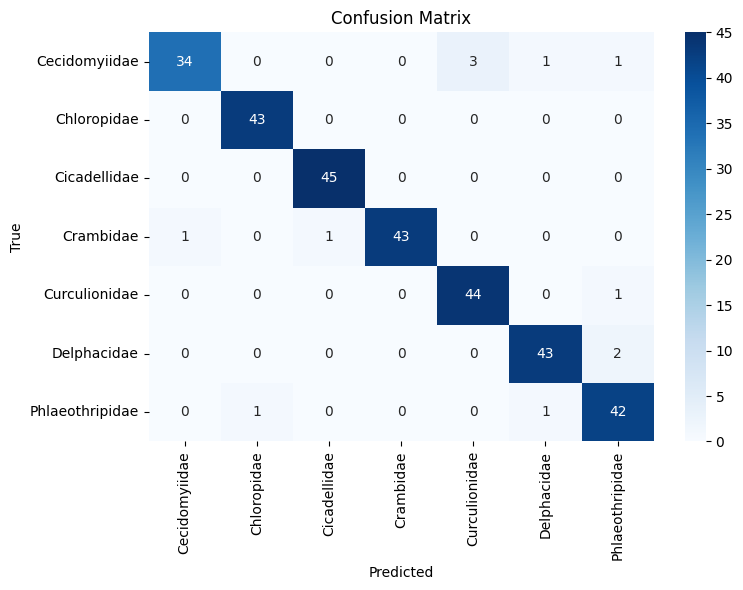

                 precision    recall  f1-score   support

  Cecidomyiidae       0.97      0.87      0.92        39
    Chloropidae       0.98      1.00      0.99        43
   Cicadellidae       0.98      1.00      0.99        45
      Crambidae       1.00      0.96      0.98        45
  Curculionidae       0.94      0.98      0.96        45
    Delphacidae       0.96      0.96      0.96        45
Phlaeothripidae       0.91      0.95      0.93        44

       accuracy                           0.96       306
      macro avg       0.96      0.96      0.96       306
   weighted avg       0.96      0.96      0.96       306



In [58]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc:.4f}')

y_true = []
y_pred = []
for images, labels_batch in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


**Section: Export**

In [59]:
model.save('models/pest_classifier')
print('Saved model to models/pest_classifier')


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=models/pest_classifier.